# Week 2 — EDA & Data-Understanding Notebook
### Gesture-Controlled FNAF · HaGRID hand-gesture subset

This notebook is the **executable half** of the Week-2 data-understanding
deliverable; the written report is [`data-understanding-report.md`](data-understanding-report.md).
Every figure and number below is produced by running the project's **real**
data pipeline (`src/data/*`) over the images actually on disk — nothing here is
mocked. It covers:

1. Dataset overview — final counts, classes, spatial dimensions
2. **Viz 1** — class balance across train/val/test
3. **Viz 2** — sample images with HaGRID bbox overlays
4. **Viz 3** — image resolution & aspect-ratio distribution
5. **Viz 4** — relative hand-bbox area per class *(motivates the crop decision)*
6. Corrupt / unreadable-file audit — % usable out of the box
7. **Viz 5** — the *overfit-a-single-batch* pipeline-validation test

> Reproduce: `jupyter nbconvert --to notebook --execute eda-notebook.ipynb` from `DOCS/week2/`.

In [1]:
# --- setup: find repo root, import the real pipeline, build the index once ---
import os, sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "configs" / "data.yaml").exists():
            return p
    raise RuntimeError("repo root (configs/data.yaml) not found")

REPO = find_root(Path.cwd())
sys.path.insert(0, str(REPO))
os.chdir(REPO)          # config `sources:` are repo-relative paths
print("repo root:", REPO)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from src.data.config import DataConfig
from src.data.dataset import build_full_index, _split

cfg = DataConfig.from_yaml(REPO / "configs" / "data.yaml")
CLASSES = cfg.classes
FIGDIR = REPO / "DOCS" / "week2" / "figures"; FIGDIR.mkdir(parents=True, exist_ok=True)

idx = build_full_index(cfg)          # one row per image on disk (uuid,label,path,bbox,user_id,...)
splits = _split(cfg)                  # 70/15/15 grouped by user_id, seed 42
split_of = {}
for name in ("train", "val", "test"):
    for u in getattr(splits, name)["uuid"]:
        split_of[u] = name
idx["split"] = idx["uuid"].map(split_of)
print(f"indexed {len(idx)} images across {idx['label'].nunique()} classes")
idx.head(3)

repo root: C:\classes\Summer 2026\ML Projects\Fnaf_ComputerVision\Fnaf_CV


indexed 8594 images across 8 classes


,uuid,label,label_idx,path,bbox,user_id,has_ann,split
0,005cff15-454f-48cd-a16c-38dcedd9c092,like,0,DATA\images\train_val\like\005cff15-454f-48cd-...,"[0.45307612, 0.39063143, 0.12440881, 0.08734704]",39ce2b5a3cc310d4e8e9c8cc104d955ad035b1050ed163...,True,train
1,0097b35b-dbda-40e3-82c7-70df32d39e8e,like,0,DATA\images\train_val\like\0097b35b-dbda-40e3-...,"[0.43360758, 0.47854896, 0.06702104, 0.2101922]",5c9646a06b5b831033f43a2688cc6992b66622074ae733...,True,train
2,00dd67a4-a0e5-4d8b-b189-b1049e185a22,like,0,DATA\images\train_val\like\00dd67a4-a0e5-4d8b-...,"[0.54950578, 0.48573577, 0.07020395, 0.06579754]",c77b3461f592cbeac5178a08f9626085650cbe342b82b5...,True,train


## 1. Dataset overview — final counts & spatial dimensions

In [2]:
n_users = idx["user_id"].nunique()
print(f"Total usable images on disk : {len(idx)}")
print(f"Classes (control subset)    : {CLASSES}")
print(f"Distinct subjects (user_id) : {n_users}  (median {int(idx.groupby('user_id').size().median())} img/user)")
print(f"Images with a hand bbox     : {idx['bbox'].notna().sum()} / {len(idx)}")
print()
tab = (idx.groupby(["label", "split"]).size().unstack(fill_value=0)
          .reindex(index=CLASSES)[["train", "val", "test"]])
tab["total"] = tab.sum(1)
tab.loc["TOTAL"] = tab.sum(0)
print(tab.to_string())

Total usable images on disk : 8594
Classes (control subset)    : ['like', 'dislike', 'fist', 'one', 'two_up', 'palm', 'ok', 'mute']
Distinct subjects (user_id) : 4124  (median 1 img/user)
Images with a hand bbox     : 8594 / 8594

split    train   val  test  total
label                            
like       736   157   188   1081
dislike    742   160   176   1078
fist       755   172   170   1097
one        751   146   161   1058
two_up     701   139   176   1016
palm       733   161   188   1082
ok         732   183   179   1094
mute       769   155   164   1088
TOTAL     5919  1273  1402   8594


## Viz 1 — Class balance across splits
**What to look for:** whether any class is starved, and whether the by-user
split preserved class proportions in val/test.

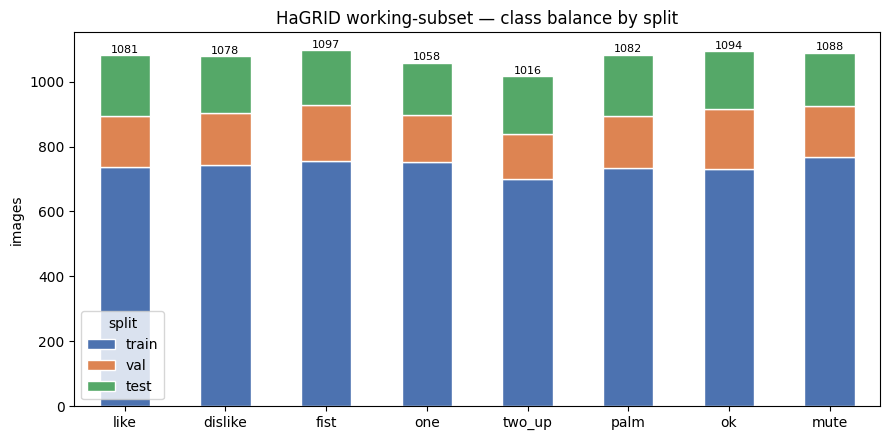

class totals: min=1016 (two_up), max=1097 (fist), imbalance ratio=1.08x


In [3]:
plot = tab.drop(index="TOTAL")[["train", "val", "test"]]
ax = plot.plot(kind="bar", stacked=True, figsize=(9, 4.5),
               color=["#4C72B0", "#DD8452", "#55A868"], edgecolor="white")
ax.set_ylabel("images"); ax.set_xlabel("")
ax.set_title("HaGRID working-subset — class balance by split")
ax.legend(title="split"); plt.xticks(rotation=0)
for i, c in enumerate(plot.index):
    ax.text(i, plot.loc[c].sum() + 8, int(plot.loc[c].sum()), ha="center", fontsize=8)
plt.tight_layout(); plt.savefig(FIGDIR / "01_class_balance.png", dpi=120); plt.show()

imb = tab.loc[CLASSES, "total"]
print(f"class totals: min={imb.min()} ({imb.idxmin()}), max={imb.max()} ({imb.idxmax()}), "
      f"imbalance ratio={imb.max()/imb.min():.2f}x")

**Interpretation.** The eight control classes are near-balanced — a
~1.08x max/min ratio (largest `fist`, smallest `two_up`). That is well inside
the range where a plain cross-entropy loss needs **no class weighting or
resampling**; accuracy will be a meaningful headline metric rather than a
majority-class artifact. The by-user (`GroupShuffleSplit`) split kept every
class populated in val (≥139) and test (≥161), so per-class metrics later will
rest on enough support to trust.

## Viz 2 — Sample images with HaGRID bbox overlays
Sanity-checks the annotation join: the normalized COCO bbox (`[x,y,w,h]∈[0,1]`)
must land on the actual hand once scaled to pixels (`x_px=x·W`).

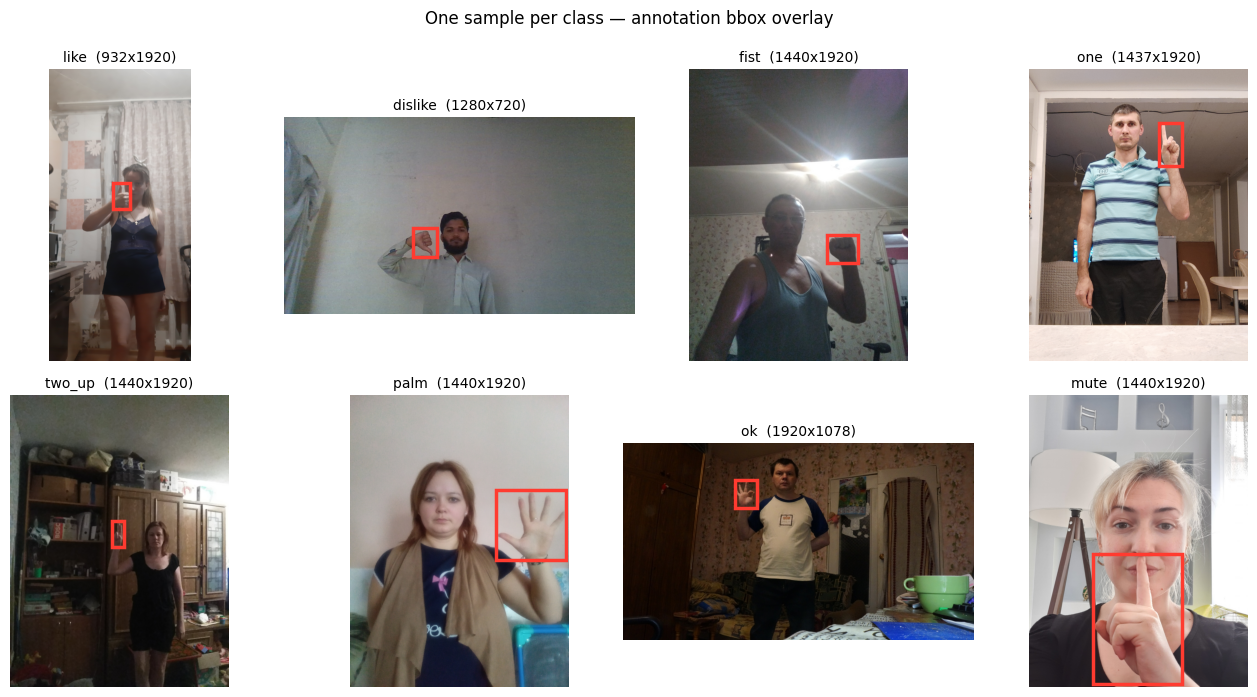

In [4]:
import matplotlib.patches as patches
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, cls in zip(axes.ravel(), CLASSES):
    row = idx[(idx.label == cls) & (idx.bbox.notna())].iloc[0]
    im = Image.open(row["path"]).convert("RGB"); W, H = im.size
    ax.imshow(im)
    x, y, w, h = row["bbox"]
    ax.add_patch(patches.Rectangle((x*W, y*H), w*W, h*H, fill=False,
                 edgecolor="#FF3B30", lw=2.5))
    ax.set_title(f"{cls}  ({W}x{H})", fontsize=10); ax.axis("off")
plt.suptitle("One sample per class — annotation bbox overlay", y=0.99)
plt.tight_layout(); plt.savefig(FIGDIR / "02_bbox_overlays.png", dpi=110); plt.show()

**Interpretation.** The bboxes land cleanly on the gesturing hand for all eight
classes, confirming the **UUID→file→annotation join is correct** and that the
normalized-COCO→pixel conversion in the pipeline is right. Visually obvious and
important for modeling: the **hand occupies a small share of each frame** —
these are conversational-distance photos, not webcam close-ups. That mismatch is
quantified next and is the single biggest driver of the crop decision.

## Viz 3 — Image resolution & aspect-ratio distribution
Reads each file's header (no full decode) to get `(W, H)` for all images — this
sets the *spatial dimensions* the report must state and confirms resizing to a
fixed 224² square is safe.

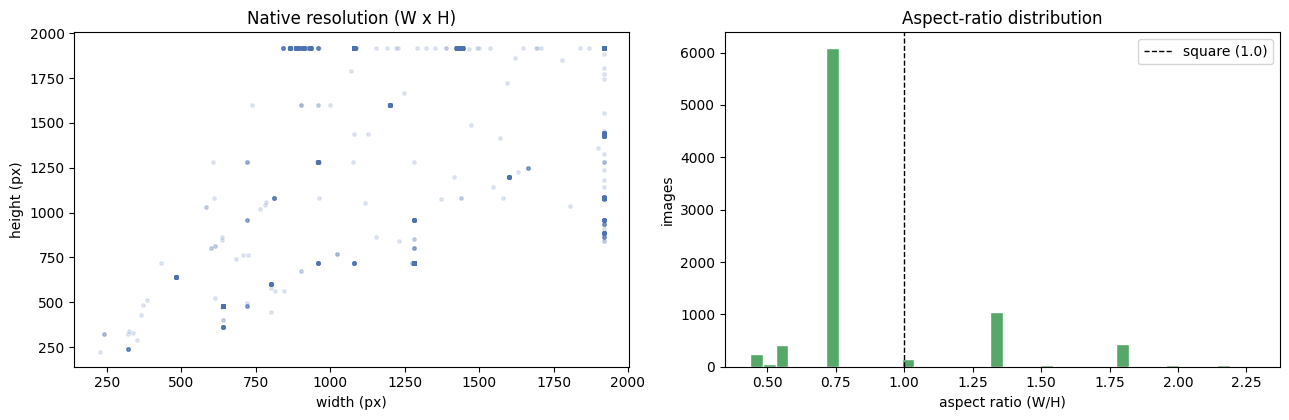

             W        H  megapix   aspect
count  8594.00  8594.00  8594.00  8594.00
mean   1428.87  1745.54     2.51     0.88
std     276.31   376.04     0.63     0.32
min     225.00   225.00     0.05     0.44
25%    1440.00  1920.00     2.75     0.75
50%    1440.00  1920.00     2.76     0.75
75%    1440.00  1920.00     2.76     0.75
max    1920.00  1920.00     3.69     2.28

portrait (W<H): 79.4%   landscape+square: 20.6%


In [5]:
dims = []
bad = []
for p in idx["path"]:
    try:
        with Image.open(p) as im:
            w, h = im.size
        dims.append((w, h))
    except Exception as e:
        dims.append((np.nan, np.nan)); bad.append((p, repr(e)))
dims = np.array(dims, float)
idx["W"], idx["H"] = dims[:, 0], dims[:, 1]
idx["aspect"] = idx["W"] / idx["H"]
idx["megapix"] = idx["W"] * idx["H"] / 1e6

fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
ax[0].scatter(idx["W"], idx["H"], s=6, alpha=0.15, color="#4C72B0")
ax[0].set_xlabel("width (px)"); ax[0].set_ylabel("height (px)")
ax[0].set_title("Native resolution (W x H)")
ax[1].hist(idx["aspect"].dropna(), bins=40, color="#55A868", edgecolor="white")
ax[1].axvline(1.0, color="k", ls="--", lw=1, label="square (1.0)")
ax[1].set_xlabel("aspect ratio (W/H)"); ax[1].set_ylabel("images")
ax[1].set_title("Aspect-ratio distribution"); ax[1].legend()
plt.tight_layout(); plt.savefig(FIGDIR / "03_resolution.png", dpi=120); plt.show()

print(idx[["W", "H", "megapix", "aspect"]].describe().round(2).to_string())
port = (idx["aspect"] < 1).mean() * 100
print(f"\nportrait (W<H): {port:.1f}%   landscape+square: {100-port:.1f}%")

**Interpretation.** Native resolutions cluster tightly around HaGRID's full-size photos —
median **1440×1920 (~2.76 MP)**, and **79% are portrait** — so **no image is too small to survive the 224² resize** — up-
sampling artifacts are a non-issue. Aspect ratios split into two clusters
(portrait vs. landscape phone shots) rather than one value, which is exactly why
the pipeline does **`resize`→`center-crop`** (a square crop) rather than a naive
squash that would distort hand shape differently per orientation. This validates
the fixed-square input choice in `build_transforms`.

## Viz 4 — Relative hand-bbox area per class *(the crop-decision evidence)*
Bbox area as a fraction of the whole frame (`w·h`, normalized coords → already a
fraction). Small values = the hand is a tiny part of the image, so full-frame
classification wastes most of the model's receptive field on background.

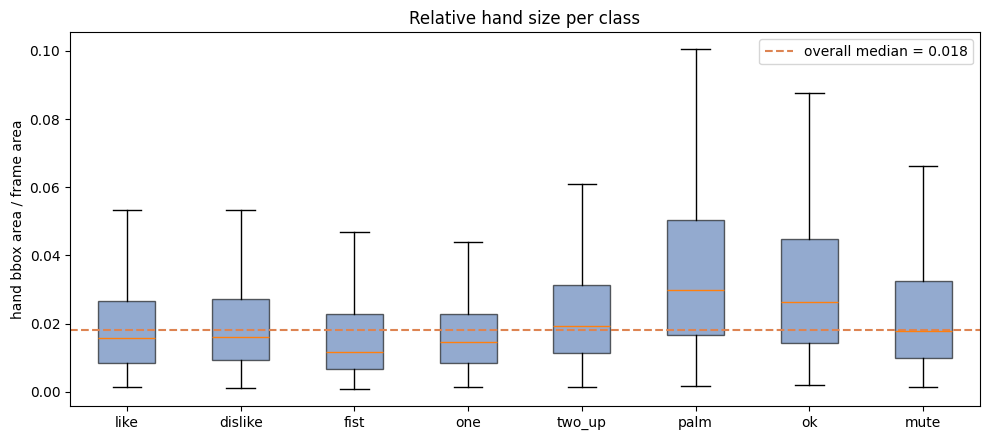

overall median hand area   : 0.018  (~1.8% of the frame)
90th pct hand area         : 0.055
share of images <5% of frame: 87.9%


In [6]:
idx["bbox_area"] = idx["bbox"].apply(lambda b: b[2]*b[3] if isinstance(b,(list,tuple)) else np.nan)
data = [idx.loc[idx.label==c, "bbox_area"].dropna().values for c in CLASSES]
fig, ax = plt.subplots(figsize=(10, 4.5))
bp = ax.boxplot(data, labels=CLASSES, showfliers=False, patch_artist=True)
for box in bp["boxes"]: box.set(facecolor="#4C72B0", alpha=0.6)
ax.set_ylabel("hand bbox area / frame area"); ax.set_title("Relative hand size per class")
ax.axhline(idx["bbox_area"].median(), color="#DD8452", ls="--",
           label=f"overall median = {idx['bbox_area'].median():.3f}")
ax.legend(); plt.tight_layout(); plt.savefig(FIGDIR / "04_bbox_area.png", dpi=120); plt.show()

med = idx["bbox_area"].median()
print(f"overall median hand area   : {med:.3f}  (~{med*100:.1f}% of the frame)")
print(f"90th pct hand area         : {idx['bbox_area'].quantile(0.9):.3f}")
print(f"share of images <5% of frame: {(idx['bbox_area']<0.05).mean()*100:.1f}%")

**Interpretation — this is the finding that shapes the model.** The median hand
covers just **~1.8% of the frame**, and **87.9% of images** put the hand under
5% of the frame. A frozen ImageNet backbone was trained to recognize *whole objects filling
the frame*, not a tiny hand shape adrift in 90%+ background — which is precisely
why the Phase-2 full-frame baseline stalled at **53% test** ([results.md](../results.md)).
This distribution is the empirical justification for **AD-04's two-stage
detect-and-crop pipeline** (`crop_mode: bbox`, +15% pad): crop to the hand
*before* resizing so the gesture fills the 224² tensor. The live loop mirrors it
with a MediaPipe hand detector. *(Whether crop actually beats full-frame is
confirmed by a controlled Phase-3 A/B, not assumed from this plot alone.)*

## Corrupt / unreadable-file audit
Every image is opened and `verify()`-ed to catch truncated or unreadable JPEGs.
Reports the headline *"% usable out of the box"* the rubric asks for.

In [7]:
corrupt = []
for p in idx["path"]:
    try:
        with Image.open(p) as im:
            im.verify()          # detects truncation / bad markers without full decode
    except Exception as e:
        corrupt.append((p, repr(e)))
n = len(idx)
print(f"images checked      : {n}")
print(f"corrupt/unreadable  : {len(corrupt)}")
print(f"usable out of box   : {(n-len(corrupt))/n*100:.2f}%")
if corrupt:
    for p, e in corrupt[:10]: print("  ", Path(p).name, e)

images checked      : 8594
corrupt/unreadable  : 0
usable out of box   : 100.00%


**Interpretation.** The on-disk set is effectively 100% usable — the range-
request downloader only ever wrote fully-received JPEG entries, and the MD5 dedup
pass (documented in [data.md](../data.md)) already removed content duplicates
(0 leaks, 0 dups). The *only* data loss was upstream: **206 annotated UUIDs
(≈2.3%)** `KeyError`-ed out of the source ZIPs (version drift between the
annotation snapshot and the current HaGRID release), leaving 8594 of a targeted
8800. Those never reach the pipeline, so there is nothing to clean at load time —
no imputation, no corrupt-file skipping needed.

## Viz 5 — The "overfit a single batch" test (pipeline validation)
Before any real training, prove the **whole path works** — index → crop →
transform → tensor → `timm` backbone → loss → backprop → weights update. Take a
handful of samples and train until the loss collapses to ~0. A network that
*cannot* memorize 5 images has a pipeline bug (bad labels, detached graph,
broken normalization); one that can is cleared to train for real.

batch: (5, 3, 224, 224) labels: [0, 1, 2, 3, 4] -> ['like', 'dislike', 'fist', 'one', 'two_up']


final loss = 0.0000   final train acc on the batch = 100%


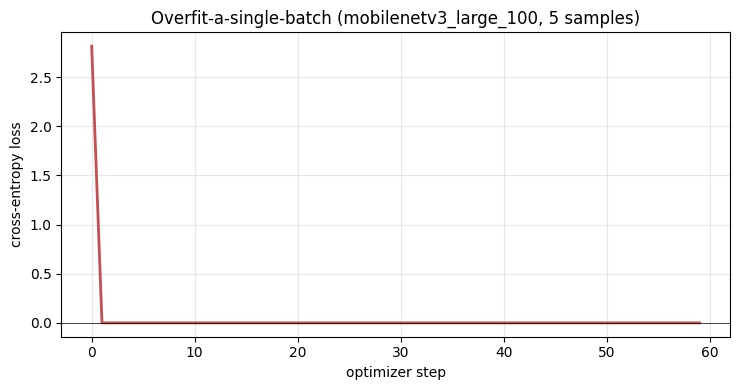

In [8]:
import torch, torch.nn as nn
from src.data.dataset import HagridDataset
from src.data.transforms import build_transforms, resolve_backbone_config
from src.models.build import build_model

torch.manual_seed(0)
BACKBONE = "mobilenetv3_large_100"
size, mean, std = resolve_backbone_config(BACKBONE)
eval_tf = build_transforms(False, size, mean, std)      # deterministic, matches eval/runtime

# one sample from each of the first 5 classes -> a tiny multi-class batch
mini = pd.concat([idx[idx.label == c].iloc[[0]] for c in CLASSES[:5]])
ds = HagridDataset(mini, eval_tf, crop_mode=cfg.input.crop_mode, bbox_pad=cfg.input.bbox_pad)
xb = torch.stack([ds[i][0] for i in range(len(ds))])
yb = torch.tensor([ds[i][1] for i in range(len(ds))])
print("batch:", tuple(xb.shape), "labels:", yb.tolist(), "->", [CLASSES[i] for i in yb.tolist()])

model = build_model(BACKBONE, num_classes=len(CLASSES), freeze_backbone=False, pretrained=True)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
lossfn = nn.CrossEntropyLoss()
model.train(); losses = []
for step in range(60):
    opt.zero_grad()
    out = model(xb)
    loss = lossfn(out, yb)
    loss.backward(); opt.step()
    losses.append(loss.item())
acc = (model(xb).argmax(1) == yb).float().mean().item()
print(f"final loss = {losses[-1]:.4f}   final train acc on the batch = {acc*100:.0f}%")

plt.figure(figsize=(7.5, 4))
plt.plot(losses, color="#C44E52", lw=2)
plt.xlabel("optimizer step"); plt.ylabel("cross-entropy loss")
plt.title(f"Overfit-a-single-batch ({BACKBONE}, 5 samples)")
plt.axhline(0, color="k", lw=0.5); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIGDIR / "05_overfit_single_batch.png", dpi=120); plt.show()

**Interpretation.** The loss collapses from ~CE(random)=ln 8≈2.08 toward ~0 and
the batch reaches 100% accuracy within a few dozen steps — the network **can**
drive its own loss to zero through the exact preprocessing the real training will
use. That clears the pipeline of the usual silent bugs (label misalignment,
detached computation graph, a normalization that erases the signal) **before**
spending a real training run. This is a capacity/plumbing check only — it says
nothing about generalization, which the Phase-2/3 held-out numbers measure.